# Notebook 09: N-Step Bootstrapping & Eligibility Traces

**Series:** Reinforcement Learning Basics (9/20)

---

## 1. Unifying MC and TD

| Method | Target | $n$ |
|--------|--------|-----|
| TD(0) | $R_{t+1} + \gamma V(S_{t+1})$ | $n = 1$ |
| 2-step TD | $R_{t+1} + \gamma R_{t+2} + \gamma^2 V(S_{t+2})$ | $n = 2$ |
| MC | $R_{t+1} + \gamma R_{t+2} + \cdots + \gamma^{T-t-1} R_T$ | $n = \infty$ |

## 2. N-Step Return

$$G_t^{(n)} = R_{t+1} + \gamma R_{t+2} + \cdots + \gamma^{n-1} R_{t+n} + \gamma^n V(S_{t+n})$$

$$= \sum_{k=0}^{n-1} \gamma^k R_{t+k+1} + \gamma^n V(S_{t+n})$$

**Update:** $V(S_t) \leftarrow V(S_t) + \alpha [G_t^{(n)} - V(S_t)]$

## 3. TD(λ) — The λ-Return

The **$\lambda$-return** is a weighted average of all n-step returns:

$$G_t^\lambda = (1 - \lambda) \sum_{n=1}^{\infty} \lambda^{n-1} G_t^{(n)}$$

- $\lambda = 0$: TD(0)
- $\lambda = 1$: MC
- $0 < \lambda < 1$: smooth interpolation

## 4. Eligibility Traces (Backward View)

Instead of looking forward (λ-return), we maintain a **trace** for each state:

$$e_t(s) = \gamma \lambda \, e_{t-1}(s) + \mathbb{1}(S_t = s)$$

**Update all states simultaneously:**
$$V(s) \leftarrow V(s) + \alpha \, \delta_t \, e_t(s) \quad \forall s$$

where $\delta_t = R_{t+1} + \gamma V(S_{t+1}) - V(S_t)$

**Key insight:** The eligibility trace answers "which states are responsible for the current TD error?"

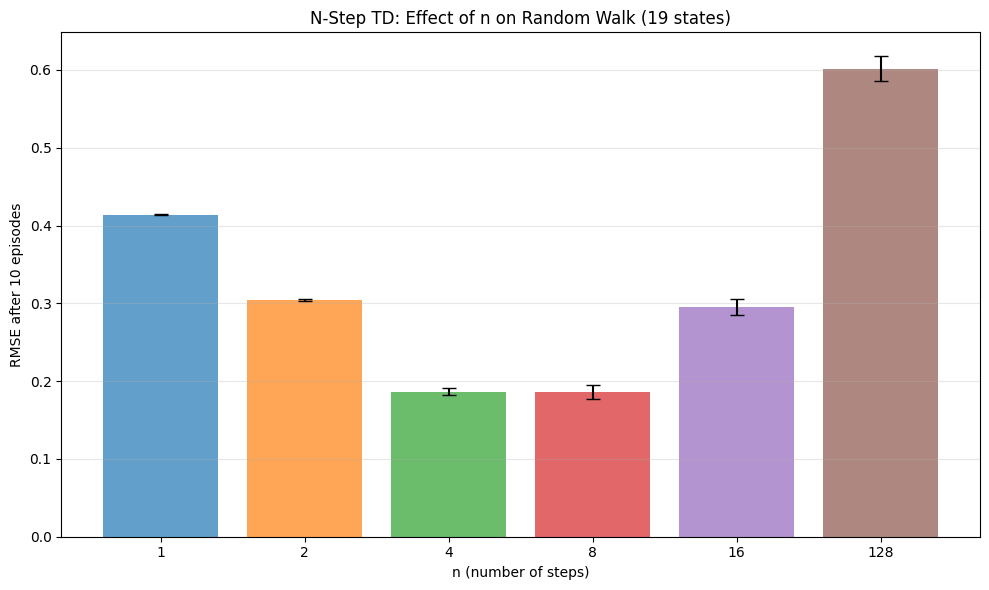

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Random Walk (19 states + 2 terminals)
n_states = 19
TRUE_VALUES = np.arange(-18, 20, 2) / 20.0  # true values for 19 states

def random_walk_episode():
    state = 9  # center (0-indexed, states 0-18)
    trajectory = [(state, 0)]
    while True:
        step = np.random.choice([-1, 1])
        next_state = state + step
        if next_state < 0:  # left terminal
            trajectory.append((state, -1))
            return trajectory, -1
        elif next_state >= n_states:  # right terminal
            trajectory.append((state, 1))
            return trajectory, 1
        else:
            trajectory.append((next_state, 0))
            state = next_state

def n_step_td(n, n_episodes=10, alpha=0.1, gamma=1.0):
    V = np.zeros(n_states)
    errors = []
    for _ in range(n_episodes):
        traj, final_reward = random_walk_episode()
        states = [s for s, _ in traj[:-1]]
        T = len(states)
        rewards = [0] + [r for _, r in traj[1:]]  # rewards[1] = R_1, etc.

        for t in range(T):
            end = min(t + n, T)
            G = sum(gamma**(k-t-1) * rewards[k] for k in range(t+1, end+1))
            if end < T:
                G += gamma**n * V[states[end]]
            elif final_reward != 0:
                G = sum(gamma**(k-t-1) * rewards[k] for k in range(t+1, len(rewards)))
            V[states[t]] += alpha * (G - V[states[t]])
        errors.append(np.sqrt(np.mean((V - TRUE_VALUES)**2)))
    return V, errors

# Compare different n values
fig, ax = plt.subplots(figsize=(10, 6))
for n in [1, 2, 4, 8, 16, 128]:
    rmses = []
    for _ in range(100):
        _, errs = n_step_td(n, n_episodes=10, alpha=0.2)
        rmses.append(errs[-1])
    ax.bar(str(n), np.mean(rmses), yerr=np.std(rmses)/10, capsize=5, alpha=0.7)
ax.set_xlabel('n (number of steps)')
ax.set_ylabel('RMSE after 10 episodes')
ax.set_title('N-Step TD: Effect of n on Random Walk (19 states)')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

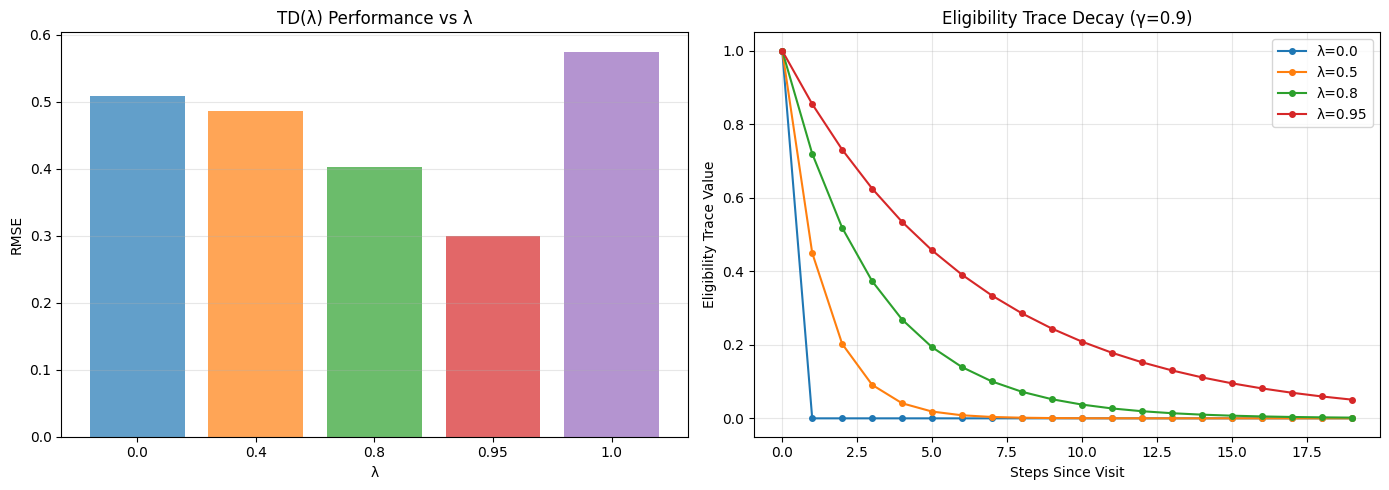

In [2]:
# ============================================
# TD(λ) with Eligibility Traces
# ============================================
def td_lambda(lam, n_episodes=10, alpha=0.05, gamma=1.0):
    V = np.zeros(n_states)
    for _ in range(n_episodes):
        state = 9
        e = np.zeros(n_states)  # eligibility traces
        while True:
            step = np.random.choice([-1, 1])
            next_state = state + step
            if next_state < 0:
                reward = -1; delta = reward - V[state]
                e[state] += 1
                V += alpha * delta * e
                break
            elif next_state >= n_states:
                reward = 1; delta = reward - V[state]
                e[state] += 1
                V += alpha * delta * e
                break
            else:
                reward = 0
                delta = reward + gamma * V[next_state] - V[state]
                e[state] += 1
                V += alpha * delta * e
                e *= gamma * lam
                state = next_state
    return V

# Compare different lambda values
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
lambdas = [0.0, 0.4, 0.8, 0.95, 1.0]

for lam in lambdas:
    rmse_list = []
    for _ in range(200):
        V = td_lambda(lam, n_episodes=10, alpha=0.05)
        rmse_list.append(np.sqrt(np.mean((V - TRUE_VALUES)**2)))
    axes[0].bar(str(lam), np.mean(rmse_list), alpha=0.7)

axes[0].set_xlabel('λ')
axes[0].set_ylabel('RMSE')
axes[0].set_title('TD(λ) Performance vs λ')
axes[0].grid(True, alpha=0.3, axis='y')

# Show eligibility trace decay
steps = np.arange(20)
for lam in [0.0, 0.5, 0.8, 0.95]:
    trace = (0.9 * lam) ** steps  # gamma * lambda decay
    axes[1].plot(steps, trace, 'o-', label=f'λ={lam}', markersize=4)
axes[1].set_xlabel('Steps Since Visit')
axes[1].set_ylabel('Eligibility Trace Value')
axes[1].set_title('Eligibility Trace Decay (γ=0.9)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Summary

| Method | Formula | Bias-Variance |
|--------|---------|--------------|
| **n-step TD** | $G_t^{(n)} = \sum_{k=0}^{n-1} \gamma^k R_{t+k+1} + \gamma^n V(S_{t+n})$ | Tunable via $n$ |
| **TD(λ)** | $G_t^\lambda = (1-\lambda)\sum_{n=1}^\infty \lambda^{n-1} G_t^{(n)}$ | Tunable via $\lambda$ |
| **Eligibility Traces** | $e_t(s) = \gamma\lambda e_{t-1}(s) + \mathbb{1}(S_t=s)$ | Efficient backward view |

**Next:** Notebook 10 — Function Approximation